In [ ]:
# https://www.kaggle.com/datasets/mirichoi0218/insurance

In [ ]:
# 1.1 Importing important libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')


In [ ]:
# 1.2 Load the dataset for regression analysis.
df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


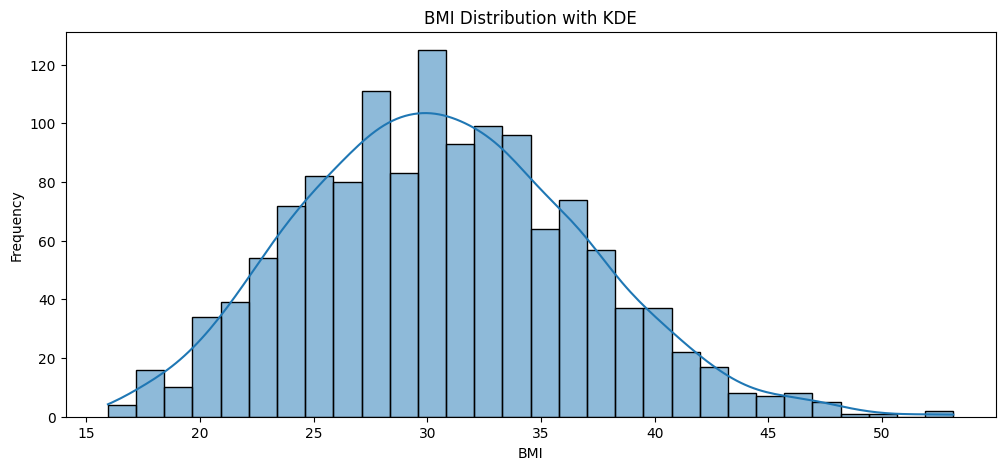

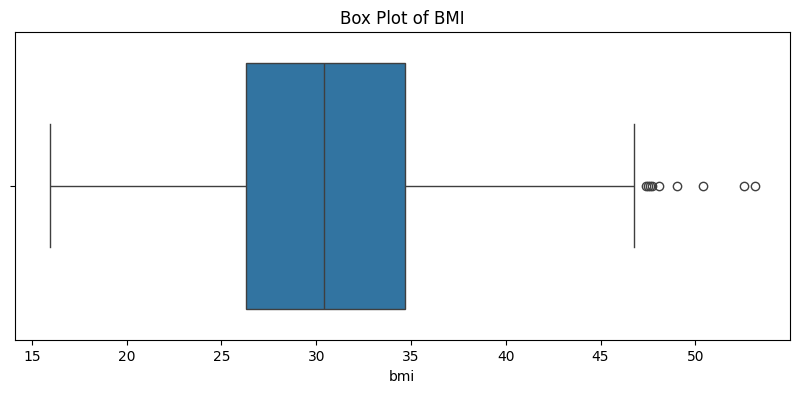

In [ ]:
# Outlier Analysis on Target Variable using histplot as distplot has been deprecated
plt.figure(figsize=(12, 5))

# Histogram with KDE for BMI
sns.histplot(df['bmi'], bins=30, kde=True) # KDE (Kernel Density Estimation)
plt.title("BMI Distribution with KDE")
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.show()

# Box plot to detect outliers
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['bmi'])
plt.title("Box Plot of BMI")
plt.show()

In [ ]:
# Remove outliers
# Compute Q1 (25th percentile) and Q3 (75th percentile)
Q1 = df['bmi'].quantile(0.25)
Q3 = df['bmi'].quantile(0.75)

# Compute IQR - IQR (Interquartile Range)
IQR = Q3 - Q1

# Define lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Print the lower and upper bounds
print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")

# Remove outliers
df_cleaned = df[(df['bmi'] >= lower_bound) & (df['bmi'] <= upper_bound)]

# Print the number of removed outliers
print(f"Outliers removed: {df.shape[0] - df_cleaned.shape[0]}")

# Display the first few rows of the cleaned dataset
df_cleaned.head()

Lower Bound: 13.7
Upper Bound: 47.290000000000006
Outliers removed: 9


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


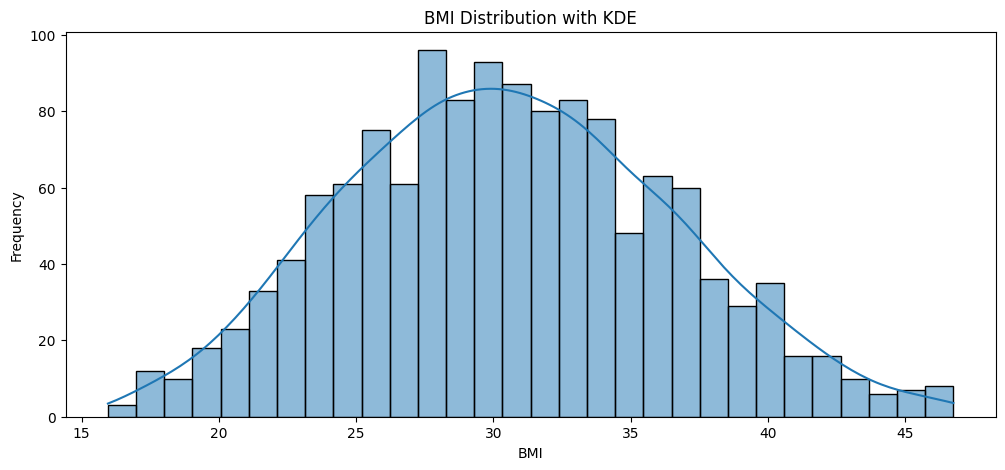

In [ ]:
# Outlier Analysis on Target Variable using histplot as histplot has been deprecated
plt.figure(figsize=(12, 5))

# Histogram with KDE for BMI
sns.histplot(df_cleaned['bmi'], bins=30, kde=True)
plt.title("BMI Distribution with KDE")
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.show()

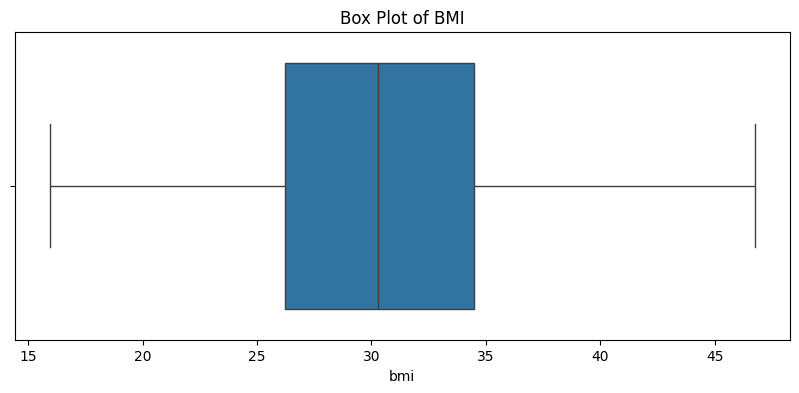

In [ ]:
# Box plot to detect outliers
plt.figure(figsize=(10, 4))
sns.boxplot(x=df_cleaned['bmi'])
plt.title("Box Plot of BMI")
plt.show()

In [ ]:
df_cleaned

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [ ]:
df_cleaned = pd.get_dummies(df_cleaned, drop_first=True)

In [ ]:
df_cleaned

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...
1333,50,30.970,3,10600.54830,True,False,True,False,False
1334,18,31.920,0,2205.98080,False,False,False,False,False
1335,18,36.850,0,1629.83350,False,False,False,True,False
1336,21,25.800,0,2007.94500,False,False,False,False,True


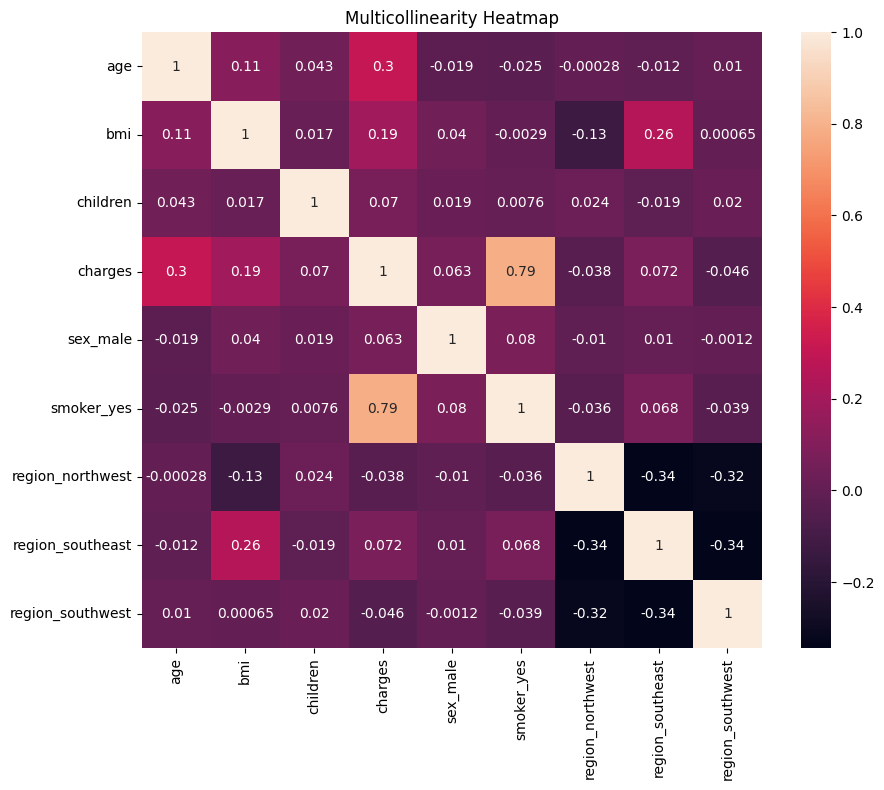

In [ ]:
# Convert categorical variables to numerical (if any exist)
#df_cleaned = pd.get_dummies(df_cleaned, drop_first=True)

# Compute the correlation matrix
corr_matrix = df_cleaned.corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True)

# Title of the heatmap
plt.title("Multicollinearity Heatmap")

# Show the plot
plt.show()

In [ ]:
# Select independent variables (predictors)
X = df_cleaned[['age', 'bmi', 'children', 'smoker_yes']]  # Multiple predictors
y = df_cleaned['charges']  # Response variable

In [ ]:
# Split data into training (75%) and testing (25%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [ ]:
# Train Multiple Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Predict charges
y_pred = model.predict(X_test)
y_train_pred = model.predict(X_train)

In [ ]:
# Model Evaluation R2
print('Testing R2 Score :', np.round(r2_score(y_test, y_pred), 2))
print('Training R2 Score :', np.round(r2_score(y_train, y_train_pred), 2))

Testing R2 Score : 0.78
Training R2 Score : 0.74


In [ ]:
# Model Evaluation RMSE
print('Training RMSE :', np.round(np.sqrt(mean_squared_error(y_train, y_train_pred)), 2))
print('Testing RMSE :', np.round(np.sqrt(mean_squared_error(y_test, y_pred)), 2))

Training RMSE : 6164.8
Testing RMSE : 5530.08


In [23]:
import pickle
with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

In [24]:
type(model)

sklearn.linear_model._base.LinearRegression